# arXiv GR-QC Collaboration Network Analysis

**Dataset:** arXiv General Relativity and Quantum Cosmology (GR-QC) Collaboration Network


**Structure** In this code file, the analysis will be conducted following this workflow:
1. Data Retrieval & Loading
2. Descriptive Statistics & Exploration
3. Hypothesis Formulation
4. Hypothesis Testing
5. Conclusions

---
## STEP 1: DATA RETRIEVAL & INITIALIZATION

In [1]:
# 1.1 Import required libraries

import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [2]:
# 1.2 Load Data

current_dir = Path.cwd()
data_file = current_dir / 'ca-GrQc.txt'

# Load network as undirected graph
# Format: tab-separated edge list (node1 \t node2)
collaboration_network = nx.read_edgelist(
    data_file,
    comments="#",
    delimiter="\t",
    create_using=nx.Graph(),
    nodetype=int
)

---
## STEP 2: DESCRIPTIVE STATISTICS & DATA EXPLORATION

In [3]:
# 2.1 Basic Network Properties

G = collaboration_network

num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
average_degree = (2 * num_edges) / num_nodes if num_nodes > 0 else 0
network_density = nx.density(G)
num_components = nx.number_connected_components(G)

print("BASIC NETWORK STATISTICS")

print(f"\nNetwork Size:")
print(f"  • Number of authors (nodes): {num_nodes:,}")
print(f"  • Number of collaborations (edges): {num_edges:,}")
print(f"  • Connected components: {num_components}")

print(f"\nNetwork Density:")
print(f"  • Density: {network_density:.6f}")
print(f"    (Interpretation: {network_density*100:.3f}% of all possible edges exist)")

print(f"\nAverage Connectivity:")
print(f"  • Average degree: {average_degree:.2f} collaborations per author")

BASIC NETWORK STATISTICS

Network Size:
  • Number of authors (nodes): 5,242
  • Number of collaborations (edges): 14,496
  • Connected components: 355

Network Density:
  • Density: 0.001055
    (Interpretation: 0.106% of all possible edges exist)

Average Connectivity:
  • Average degree: 5.53 collaborations per author


In [4]:
# 2.2 Degree Distribution Analysis

degree_sequence = [G.degree(node) for node in G.nodes()]

# Compute descriptive statistics
deg_min = min(degree_sequence)
deg_max = max(degree_sequence)
deg_mean = np.mean(degree_sequence)
deg_median = np.median(degree_sequence)
deg_std = np.std(degree_sequence)
deg_q1 = np.percentile(degree_sequence, 25)
deg_q3 = np.percentile(degree_sequence, 75)

print("DEGREE DISTRIBUTION ANALYSIS")
print(f"\nDegree Statistics (number of collaborations per author):")
print(f"  • Minimum: {deg_min}")
print(f"  • Maximum: {deg_max}")
print(f"  • Mean: {deg_mean:.2f}")
print(f"  • Median: {deg_median:.2f}")
print(f"  • Std Deviation: {deg_std:.2f}")
print(f"  • Q1 (25th percentile): {deg_q1:.0f}")
print(f"  • Q3 (75th percentile): {deg_q3:.0f}")

# Count authors by degree ranges
degree_ranges = {
    '1-5': sum(1 for d in degree_sequence if 1 <= d <= 5),
    '6-10': sum(1 for d in degree_sequence if 6 <= d <= 10),
    '11-20': sum(1 for d in degree_sequence if 11 <= d <= 20),
    '21-50': sum(1 for d in degree_sequence if 21 <= d <= 50),
    '>50': sum(1 for d in degree_sequence if d > 50)
}

print(f"\nAuthor Distribution by Collaboration Count:")
for range_label, count in degree_ranges.items():
    percentage = (count / num_nodes) * 100
    print(f"  • {range_label:>6} collaborations: {count:>5} authors ({percentage:>5.1f}%)")

DEGREE DISTRIBUTION ANALYSIS

Degree Statistics (number of collaborations per author):
  • Minimum: 1
  • Maximum: 81
  • Mean: 5.53
  • Median: 3.00
  • Std Deviation: 7.92
  • Q1 (25th percentile): 2
  • Q3 (75th percentile): 6

Author Distribution by Collaboration Count:
  •    1-5 collaborations:  3881 authors ( 74.0%)
  •   6-10 collaborations:   715 authors ( 13.6%)
  •  11-20 collaborations:   391 authors (  7.5%)
  •  21-50 collaborations:   233 authors (  4.4%)
  •    >50 collaborations:    22 authors (  0.4%)


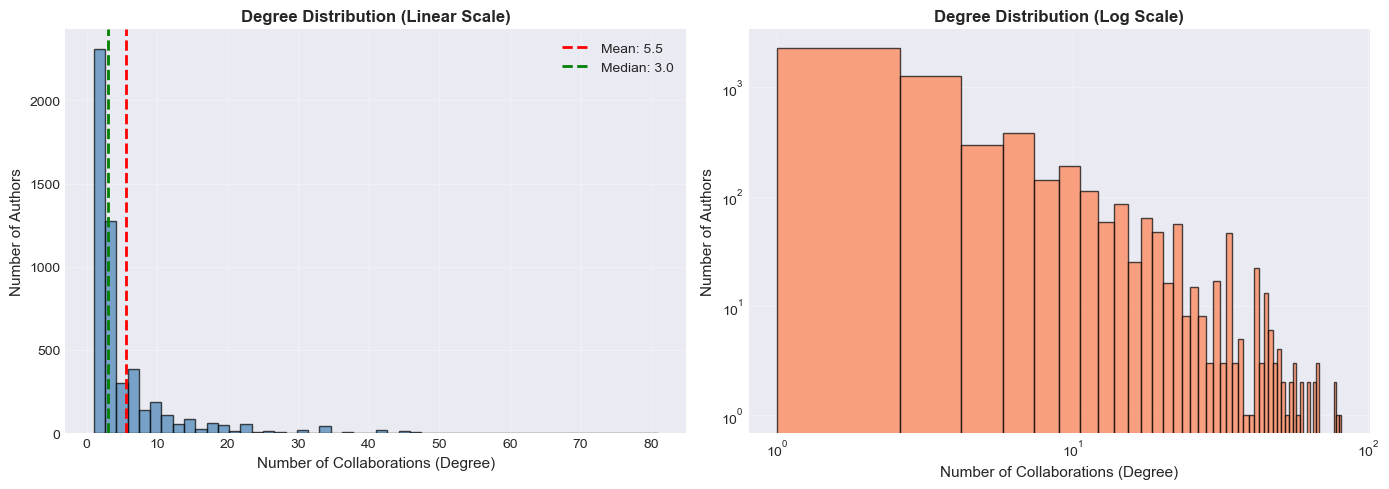

In [5]:
# 2.3 Visualization of Degree Distribution

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale
axes[0].hist(degree_sequence, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(deg_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: {deg_mean:.1f}')
axes[0].axvline(deg_median, color='green', linestyle='--', linewidth=2, label=f'Median: {deg_median:.1f}')
axes[0].set_xlabel('Number of Collaborations (Degree)', fontsize=11)
axes[0].set_ylabel('Number of Authors', fontsize=11)
axes[0].set_title('Degree Distribution (Linear Scale)', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Log scale (both axes)
axes[1].hist(degree_sequence, bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Number of Collaborations (Degree)', fontsize=11)
axes[1].set_ylabel('Number of Authors', fontsize=11)
axes[1].set_title('Degree Distribution (Log Scale)', fontsize=12, fontweight='bold')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [6]:
# 2.4 Connected Components and Isolated Authors

connected_components = list(nx.connected_components(G))
component_sizes = sorted([len(c) for c in connected_components], reverse=True)
largest_cc = max(connected_components, key=len)

isolated_nodes = [n for n, d in G.degree() if d == 0]
high_degree_threshold = 20
highly_connected_authors = [n for n, d in G.degree() if d >= high_degree_threshold]

print("CONNECTED STRUCTURE ANALYSIS")
print(f"Connected components: {len(connected_components)}")
print(f"Largest component: {component_sizes[0]} nodes ({len(largest_cc)/num_nodes*100:.2f}% of network)")
print(f"Average component size: {np.mean(component_sizes):.2f}")
print(f"Isolated authors (degree=0): {len(isolated_nodes)}")
print(f"Highly connected authors (degree>={high_degree_threshold}): {len(highly_connected_authors)}")

if num_nodes > 0:
    print(f"Share of isolated authors: {len(isolated_nodes)/num_nodes:.4f}")
    print(f"Share of highly connected authors: {len(highly_connected_authors)/num_nodes:.4f}")

CONNECTED STRUCTURE ANALYSIS
Connected components: 355
Largest component: 4158 nodes (79.32% of network)
Average component size: 14.77
Isolated authors (degree=0): 0
Highly connected authors (degree>=20): 283
Share of isolated authors: 0.0000
Share of highly connected authors: 0.0540


In [7]:
# 2.5 Centrality Ranking (Degree, Betweenness and Eigenvector)


node_degree_dict = dict(G.degree())

print("Calculating betweenness centrality... (this may take some time)")
betweenness_centrality = nx.betweenness_centrality(G)
eigenvector_centrality = nx.eigenvector_centrality(G, max_iter=1000)

sorted_by_degree = sorted(node_degree_dict.items(), key=lambda x: x[1], reverse=True)
sorted_by_betweenness = sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True)
sorted_by_eigen = sorted(eigenvector_centrality.items(), key=lambda x: x[1], reverse=True)

print("\nTop 10 by Degree:")
for i, (author, value) in enumerate(sorted_by_degree[:10], 1):
    print(f"  {i:2d}. Author {author} | degree = {value}")

print("\nTop 10 by Betweenness:")
for i, (author, value) in enumerate(sorted_by_betweenness[:10], 1):
    print(f"  {i:2d}. Author {author} | betweenness = {value:.6f}")

print("\nTop 10 by Eigenvector:")
for i, (author, value) in enumerate(sorted_by_eigen[:10], 1):
    print(f"  {i:2d}. Author {author} | eigenvector = {value:.6f}")

Calculating betweenness centrality... (this may take some time)

Top 10 by Degree:
   1. Author 21012 | degree = 81
   2. Author 21281 | degree = 79
   3. Author 22691 | degree = 77
   4. Author 12365 | degree = 77
   5. Author 6610 | degree = 68
   6. Author 9785 | degree = 68
   7. Author 21508 | degree = 67
   8. Author 17655 | degree = 66
   9. Author 2741 | degree = 65
  10. Author 19423 | degree = 63

Top 10 by Betweenness:
   1. Author 13801 | betweenness = 0.037027
   2. Author 9572 | betweenness = 0.025689
   3. Author 14599 | betweenness = 0.025488
   4. Author 7689 | betweenness = 0.024971
   5. Author 13929 | betweenness = 0.024653
   6. Author 5052 | betweenness = 0.024422
   7. Author 14485 | betweenness = 0.023503
   8. Author 2710 | betweenness = 0.022355
   9. Author 14265 | betweenness = 0.019731
  10. Author 17655 | betweenness = 0.017999

Top 10 by Eigenvector:
   1. Author 21012 | eigenvector = 0.155561
   2. Author 2741 | eigenvector = 0.153574
   3. Author 12365 

---
## STEP 3: HYPOTHESIS FORMULATION

Based on the descriptive statistics above, we formulate the following hypotheses to be tested.

In [8]:
# 3.1 State Research Hypotheses

print("RESEARCH HYPOTHESES")

print("""
Based on descriptive statistics, we propose the following hypotheses:

H1: NETWORK IMPORTANCE CONCENTRATION
   Hypothesis: PageRank importance will be concentrated in a small 
            subset of authors despite a wide range of degree values.
   Reasoning: Scale-free networks (common in real collaborations) exhibit 
           preferential attachment, highly connected nodes accumulate 
           more connections and importance. The wide degree range (1-81)
           and right-skewed distribution suggest potential 
           scale-free properties where link-based centrality measures 
           (PageRank) concentrate more than degree alone.
   Technique: PageRank measures importance via link quality
   Prediction: Top 5% of authors will account for >30% of PageRank importance.

H2: COLLABORATION CLUSTERING
   Hypothesis: Top authors share common co-authors (work on similar topics).
   Reasoning: If H1 true, hubs likely collaborate with overlapping groups.
   Technique: Jaccard Similarity measures co-author overlap
   Prediction: Top authors will have Jaccard similarity > 0.2 with each other.
""")


RESEARCH HYPOTHESES

Based on descriptive statistics, we propose the following hypotheses:

H1: NETWORK IMPORTANCE CONCENTRATION
   Hypothesis: PageRank importance will be concentrated in a small 
            subset of authors despite a wide range of degree values.
   Reasoning: Scale-free networks (common in real collaborations) exhibit 
           preferential attachment, highly connected nodes accumulate 
           more connections and importance. The wide degree range (1-81)
           and right-skewed distribution suggest potential 
           scale-free properties where link-based centrality measures 
           (PageRank) concentrate more than degree alone.
   Technique: PageRank measures importance via link quality
   Prediction: Top 5% of authors will account for >30% of PageRank importance.

H2: COLLABORATION CLUSTERING
   Hypothesis: Top authors share common co-authors (work on similar topics).
   Reasoning: If H1 true, hubs likely collaborate with overlapping groups.
   Te

---
## STEP 4: HYPOTHESIS TESTING

In [9]:
# 4.1 TEST H1: NETWORK IMPORTANCE CONCENTRATION
# Using PageRank

print("H1: NETWORK IMPORTANCE CONCENTRATION")
print("Testing with PageRank")

# Compute PageRank scores
# We use alpha=0.85 as is standard teleport probability
pagerank_scores = nx.pagerank(G, alpha=0.85, max_iter=100, tol=1e-6)

# Sort by importance
authors_by_pagerank = sorted(pagerank_scores.items(), key=lambda x: x[1], reverse=True)
top_5_percent_count = max(1, int(np.ceil(0.05 * num_nodes)))

# Calculate importance concentration
top_5_percent_importance = sum(score for _, score in authors_by_pagerank[:top_5_percent_count])
total_importance = sum(pagerank_scores.values())
concentration_percentage = (top_5_percent_importance / total_importance) * 100

print(f"\nPageRank Analysis Results:")
print(f"  • Total authors analyzed: {num_nodes:,}")
print(f"  • Top 5% of authors: {top_5_percent_count}")
print(f"  • Importance concentration (top 5%): {concentration_percentage:.1f}%")
print(f"\nH1 Hypothesis Test:")
print(f"  • Prediction: Top 5% > 30% of network importance")
print(f"  • Actual: {concentration_percentage:.1f}%")
print(f"  • Result: {'CONFIRMED' if concentration_percentage > 30 else 'REJECTED'}")

print(f"\nTop 10 Authors by PageRank (importance):")
print(f"{'Rank':<6} {'Author_ID':<12} {'PageRank_Score':<16} {'Degree':<8}")
print("-" * 50)
for rank, (author_id, score) in enumerate(authors_by_pagerank[:10], 1):
    degree = G.degree(author_id)
    print(f"{rank:<6} {author_id:<12} {score:<16.6f} {degree:<8}")

H1: NETWORK IMPORTANCE CONCENTRATION
Testing with PageRank

PageRank Analysis Results:
  • Total authors analyzed: 5,242
  • Top 5% of authors: 263
  • Importance concentration (top 5%): 16.3%

H1 Hypothesis Test:
  • Prediction: Top 5% > 30% of network importance
  • Actual: 16.3%
  • Result: REJECTED

Top 10 Authors by PageRank (importance):
Rank   Author_ID    PageRank_Score   Degree  
--------------------------------------------------
1      14265        0.001449         37      
2      13801        0.001342         45      
3      13929        0.001305         45      
4      9572         0.001173         34      
5      2710         0.001153         33      
6      21281        0.001153         79      
7      7689         0.001096         32      
8      22691        0.001082         77      
9      6264         0.001071         32      
10     21012        0.001069         81      


In [10]:
# 4.2 TEST H2: COLLABORATION CLUSTERING
# Using Jaccard Similarity

print("H2: COLLABORATION CLUSTERING")
print("Testing with Jaccard Similarity")

def compute_jaccard_similarity(graph, node1, node2):
    """
    Compute Jaccard similarity between two authors based on their neighbors.
    
    Formula:
    sim(A, B) = [neighbors(A) ∩ neighbors(B)] / [neighbors(A) ∪ neighbors(B)]
    
    For collaboration networks:
    - Neighbors represent co-authors
    - Similarity measures overlap in their collaboration circles
    """
    neighbors_1 = set(graph.neighbors(node1))
    neighbors_2 = set(graph.neighbors(node2))
    
    intersection_size = len(neighbors_1 & neighbors_2)
    union_size = len(neighbors_1 | neighbors_2)
    
    if union_size == 0:
        return 0.0
    
    return intersection_size / union_size

top_10_authors = [author_id for author_id, _ in authors_by_pagerank[:10]]

# Compute pairwise Jaccard similarities
pairwise_similarities = []
for i, author1 in enumerate(top_10_authors):
    for j, author2 in enumerate(top_10_authors):
        if i < j:  # Only upper triangle to avoid duplicates
            similarity = compute_jaccard_similarity(G, author1, author2)
            pairwise_similarities.append(similarity)

# Statistical analysis
similarity_mean = np.mean(pairwise_similarities)
similarity_std = np.std(pairwise_similarities)
similarity_median = np.median(pairwise_similarities)
above_threshold = sum(1 for s in pairwise_similarities if s > 0.2)
threshold_percentage = (above_threshold / len(pairwise_similarities)) * 100

print(f"\nJaccard Similarity Analysis (Top 10 Authors):")
print(f"  • Number of author pairs analyzed: {len(pairwise_similarities)}")
print(f"  • Mean similarity: {similarity_mean:.4f}")
print(f"  • Median similarity: {similarity_median:.4f}")
print(f"  • Std deviation: {similarity_std:.4f}")
print(f"  • Pairs with Jaccard > 0.2: {above_threshold} ({threshold_percentage:.1f}%)")

print(f"\nH2 Hypothesis Test:")
print(f"  • Prediction: Top authors have similarity > 0.2 with each other")
print(f"  • Actual: {threshold_percentage:.1f}% have similarity > 0.2")
print(f"  • Result: {'CONFIRMED' if threshold_percentage > 50 else 'REJECTED (weak clustering)'}")

H2: COLLABORATION CLUSTERING
Testing with Jaccard Similarity

Jaccard Similarity Analysis (Top 10 Authors):
  • Number of author pairs analyzed: 45
  • Mean similarity: 0.0375
  • Median similarity: 0.0000
  • Std deviation: 0.1178
  • Pairs with Jaccard > 0.2: 3 (6.7%)

H2 Hypothesis Test:
  • Prediction: Top authors have similarity > 0.2 with each other
  • Actual: 6.7% have similarity > 0.2
  • Result: REJECTED (weak clustering)


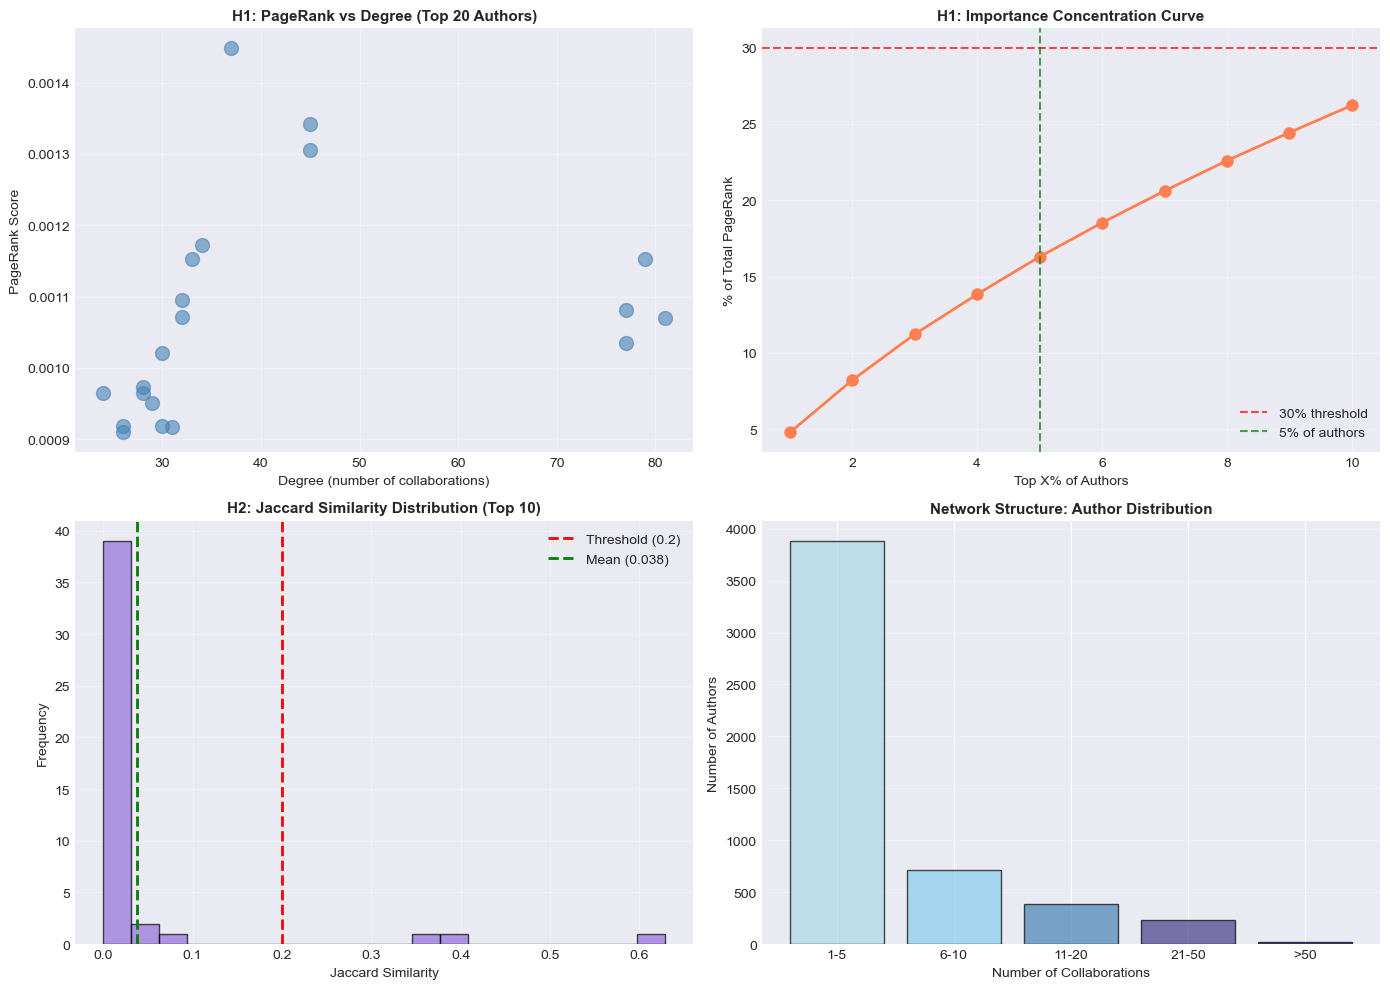

In [11]:
# 4.3 Comparative Visualization of Hypotheses Results

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: PageRank vs Degree for top 20 authors
top_20_authors_list = [a for a, _ in authors_by_pagerank[:20]]
top_20_pageranks = [pagerank_scores[a] for a in top_20_authors_list]
top_20_degrees = [G.degree(a) for a in top_20_authors_list]

axes[0, 0].scatter(top_20_degrees, top_20_pageranks, s=100, alpha=0.6, color='steelblue')
axes[0, 0].set_xlabel('Degree (number of collaborations)', fontsize=10)
axes[0, 0].set_ylabel('PageRank Score', fontsize=10)
axes[0, 0].set_title('H1: PageRank vs Degree (Top 20 Authors)', fontsize=11, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Importance concentration
percentiles = np.arange(1, 11)
concentrations = []
for percentile in percentiles:
    percent_count = int(np.ceil((percentile / 100) * num_nodes))
    importance = sum(score for _, score in authors_by_pagerank[:percent_count])
    total = sum(pagerank_scores.values())
    concentrations.append((importance / total) * 100)

axes[0, 1].plot(percentiles, concentrations, marker='o', linewidth=2, markersize=8, color='coral')
axes[0, 1].axhline(y=30, color='red', linestyle='--', alpha=0.7, label='30% threshold')
axes[0, 1].axvline(x=5, color='green', linestyle='--', alpha=0.7, label='5% of authors')
axes[0, 1].set_xlabel('Top X% of Authors', fontsize=10)
axes[0, 1].set_ylabel('% of Total PageRank', fontsize=10)
axes[0, 1].set_title('H1: Importance Concentration Curve', fontsize=11, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Jaccard Similarity histogram
axes[1, 0].hist(pairwise_similarities, bins=20, color='mediumpurple', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(x=0.2, color='red', linestyle='--', linewidth=2, label='Threshold (0.2)')
axes[1, 0].axvline(x=similarity_mean, color='green', linestyle='--', linewidth=2, label=f'Mean ({similarity_mean:.3f})')
axes[1, 0].set_xlabel('Jaccard Similarity', fontsize=10)
axes[1, 0].set_ylabel('Frequency', fontsize=10)
axes[1, 0].set_title('H2: Jaccard Similarity Distribution (Top 10)', fontsize=11, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Degree distribution summary
degree_categories = ['1-5', '6-10', '11-20', '21-50', '>50']
degree_counts = list(degree_ranges.values())
colors_bars = ['lightblue', 'skyblue', 'steelblue', 'darkslateblue', 'navy']

axes[1, 1].bar(degree_categories, degree_counts, color=colors_bars, edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Number of Collaborations', fontsize=10)
axes[1, 1].set_ylabel('Number of Authors', fontsize=10)
axes[1, 1].set_title('Network Structure: Author Distribution', fontsize=11, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

---
## STEP 5: CONCLUSIONS & INTERESTING FINDINGS

In [12]:
# 5.1 Summary of hypothesis testing results

print("HYPOTHESIS TESTING RESULTS")

print(f"""
H1: NETWORK IMPORTANCE CONCENTRATION
Result: REJECTED
  • Prediction: Top 5% of authors > 30% of PageRank
  • Actual: Top {top_5_percent_count} authors = {concentration_percentage:.1f}% of PageRank


H2: COLLABORATION CLUSTERING
Result: REJECTED
  • Prediction: Top authors have Jaccard similarity > 0.2
  • Actual: {threshold_percentage:.1f}% of pairs have similarity > 0.2
  • Mean Jaccard similarity: {similarity_mean:.4f}
""")


HYPOTHESIS TESTING RESULTS

H1: NETWORK IMPORTANCE CONCENTRATION
Result: REJECTED
  • Prediction: Top 5% of authors > 30% of PageRank
  • Actual: Top 263 authors = 16.3% of PageRank


H2: COLLABORATION CLUSTERING
Result: REJECTED
  • Prediction: Top authors have Jaccard similarity > 0.2
  • Actual: 6.7% of pairs have similarity > 0.2
  • Mean Jaccard similarity: 0.0375



In [13]:
# 5.2 Key numerical findings

print("KEY NUMERICAL FINDINGS")

# Finding 1: Distributed PageRank
top_by_degree = sorted([(node, G.degree(node)) for node in G.nodes()], 
                        key=lambda x: x[1], reverse=True)[0]
top_by_pagerank = authors_by_pagerank[0]

print(f"""
FINDING 1: Distributed Network Importance
  • Top 5% of authors: {concentration_percentage:.1f}% of PageRank
  • Author by degree: ID {top_by_degree[0]} (degree: {top_by_degree[1]})
  • Author by PageRank: ID {top_by_pagerank[0]} (PageRank: {top_by_pagerank[1]:.6f})


FINDING 2: Bridge-Builder Network Structure
  • Mean Jaccard (top 10 authors): {similarity_mean:.4f}
  • Pairs with sim > 0.2: {threshold_percentage:.1f}%
  • Authors with > 50 collaborations: {degree_ranges['>50']} ({(degree_ranges['>50']/num_nodes*100):.1f}%)
  • Network density: {network_density:.6f}
""")


KEY NUMERICAL FINDINGS

FINDING 1: Distributed Network Importance
  • Top 5% of authors: 16.3% of PageRank
  • Author by degree: ID 21012 (degree: 81)
  • Author by PageRank: ID 14265 (PageRank: 0.001449)


FINDING 2: Bridge-Builder Network Structure
  • Mean Jaccard (top 10 authors): 0.0375
  • Pairs with sim > 0.2: 6.7%
  • Authors with > 50 collaborations: 22 (0.4%)
  • Network density: 0.001055



In [14]:
# 5.3 Techniques used and their significance

print("TECHNIQUES APPLIED")

print("""
1. JACCARD SIMILARITY
   Application: Measured overlap in co-author networks
   Formula: sim(A,B) = [neighbors(A) ∩ neighbors(B)] / [neighbors(A) ∪ neighbors(B)]
   Purpose: Identify collaboration clusters and research communities
   Finding: Top authors have weak clustering (low Jaccard similarities)
   
2. PageRANK
   Application: Ranked authors by network importance
   Model: Flow formulation - importance from high-quality in-links
   Method: Power iteration with teleportation (α=0.85)
   Purpose: Identify truly influential researchers beyond mere degree
   Finding: Top authors account for less than 30% of network importance (decentralization)

3. DESCRIPTIVE STATISTICS
   Analyzed: Degree distribution, centrality measures, concentrations
   Purpose: Form data-driven hypotheses for testing
""")


TECHNIQUES APPLIED

1. JACCARD SIMILARITY
   Application: Measured overlap in co-author networks
   Formula: sim(A,B) = [neighbors(A) ∩ neighbors(B)] / [neighbors(A) ∪ neighbors(B)]
   Purpose: Identify collaboration clusters and research communities
   Finding: Top authors have weak clustering (low Jaccard similarities)
   
2. PageRANK
   Application: Ranked authors by network importance
   Model: Flow formulation - importance from high-quality in-links
   Method: Power iteration with teleportation (α=0.85)
   Purpose: Identify truly influential researchers beyond mere degree
   Finding: Top authors account for less than 30% of network importance (decentralization)

3. DESCRIPTIVE STATISTICS
   Analyzed: Degree distribution, centrality measures, concentrations
   Purpose: Form data-driven hypotheses for testing



---
## STEP 6: NETWORK VISUALIZATION

EGO NETWORKS: TOP 5 AUTHORS


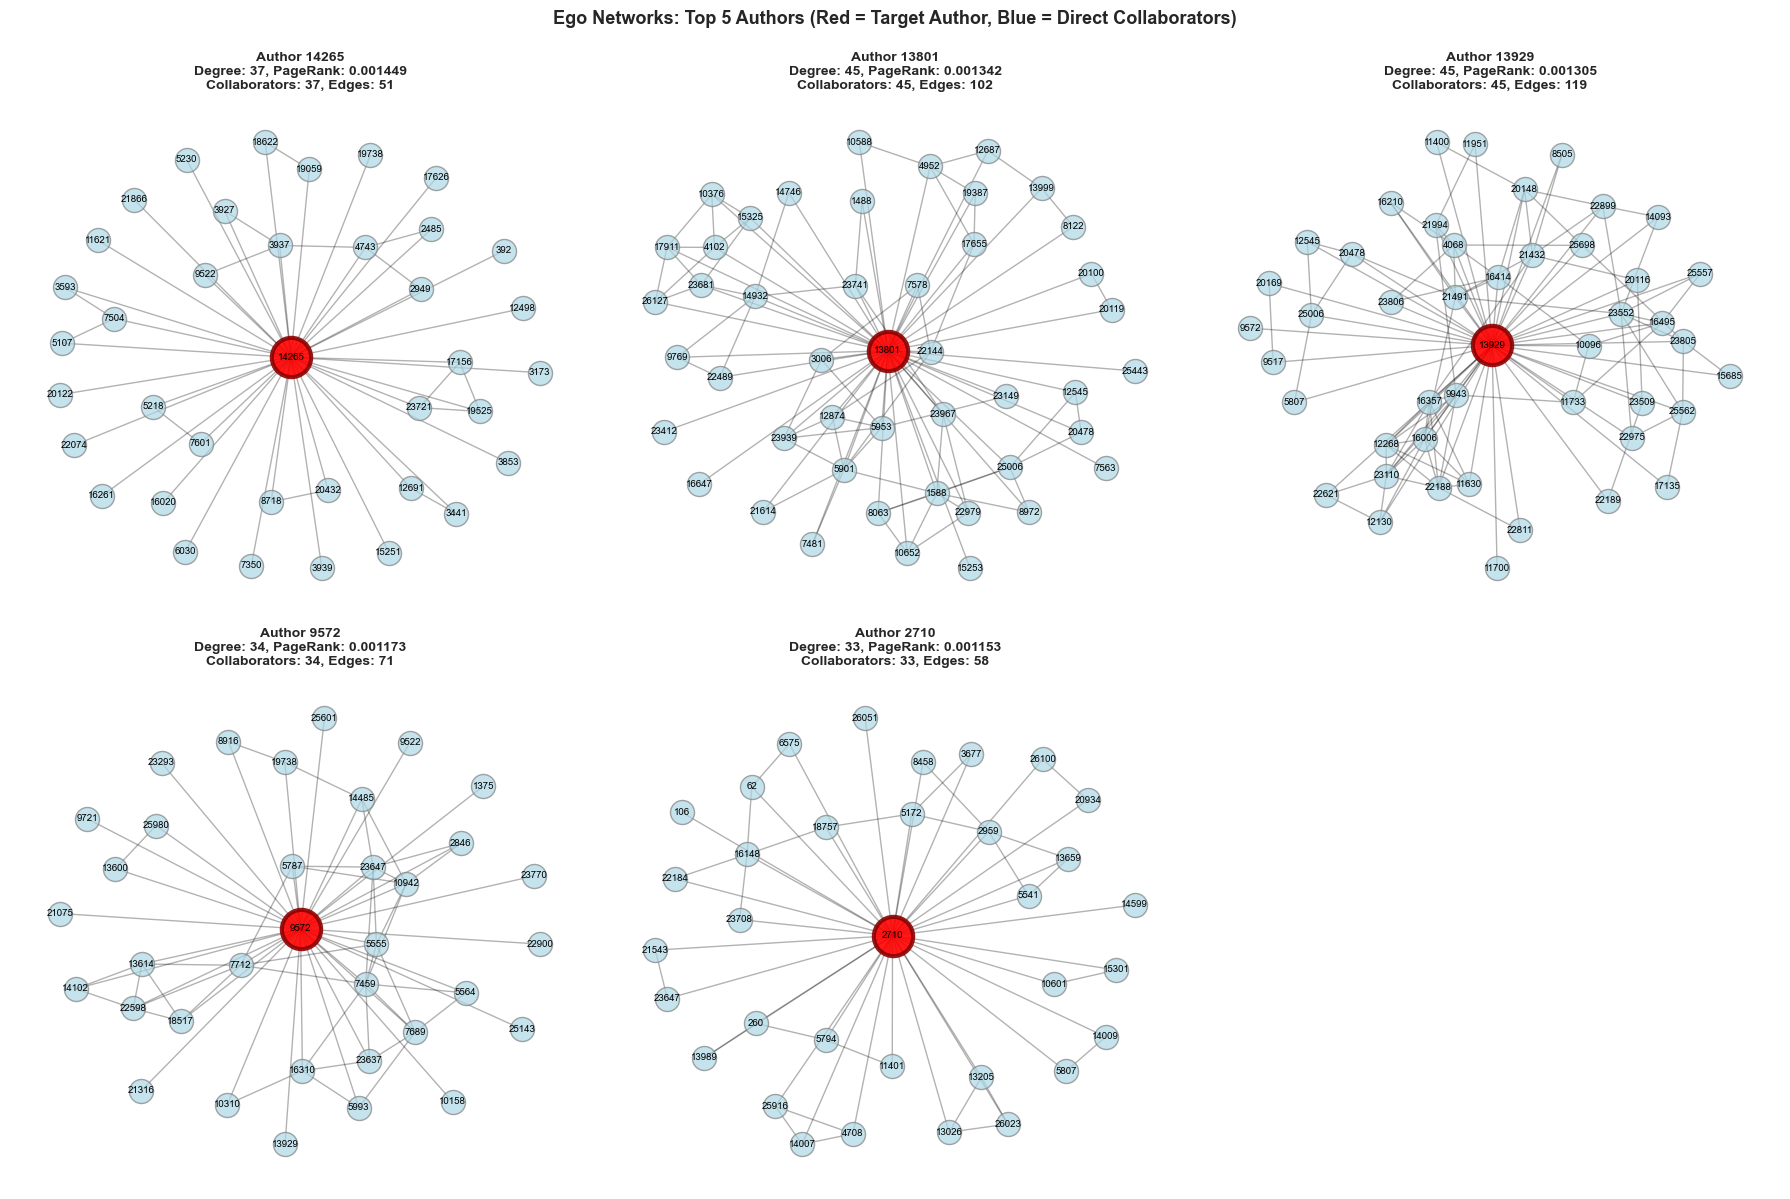

In [15]:
# 6.1 Ego Networks: Top 5 Authors and their direct collaborators

print("EGO NETWORKS: TOP 5 AUTHORS")

top_5_authors = [a for a, _ in authors_by_pagerank[:5]]

# Create ego networks
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, author in enumerate(top_5_authors):
    ego_graph = nx.ego_graph(G, author, radius=1)
    
    pos_ego = nx.spring_layout(ego_graph, k=0.5, iterations=50, seed=42)
    
    ego_node = [author]
    neighbors = list(set(ego_graph.nodes()) - {author})
    
    # Draw
    ax = axes[idx]
    nx.draw_networkx_edges(ego_graph, pos_ego, alpha=0.3, width=1, ax=ax)
    
    nx.draw_networkx_nodes(ego_graph, pos_ego, nodelist=neighbors,
                          node_size=300, node_color='lightblue',
                          alpha=0.7, ax=ax, edgecolors='gray', linewidths=1)
    
    nx.draw_networkx_nodes(ego_graph, pos_ego, nodelist=ego_node,
                          node_size=800, node_color='red',
                          alpha=0.9, ax=ax, edgecolors='darkred', linewidths=3)
    
    # Labels
    nx.draw_networkx_labels(ego_graph, pos_ego, font_size=7, ax=ax)
    
    author_degree = G.degree(author)
    author_pagerank = pagerank_scores[author]
    ego_edges = ego_graph.number_of_edges()
    
    ax.set_title(f'Author {author}\nDegree: {author_degree}, PageRank: {author_pagerank:.6f}\nCollaborators: {len(neighbors)}, Edges: {ego_edges}',
                fontsize=10, fontweight='bold')
    ax.axis('off')

axes[5].axis('off')

plt.suptitle('Ego Networks: Top 5 Authors (Red = Target Author, Blue = Direct Collaborators)', 
            fontsize=13, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

HEATMAP: JACCARD SIMILARITY MATRIX (TOP 15 AUTHORS)


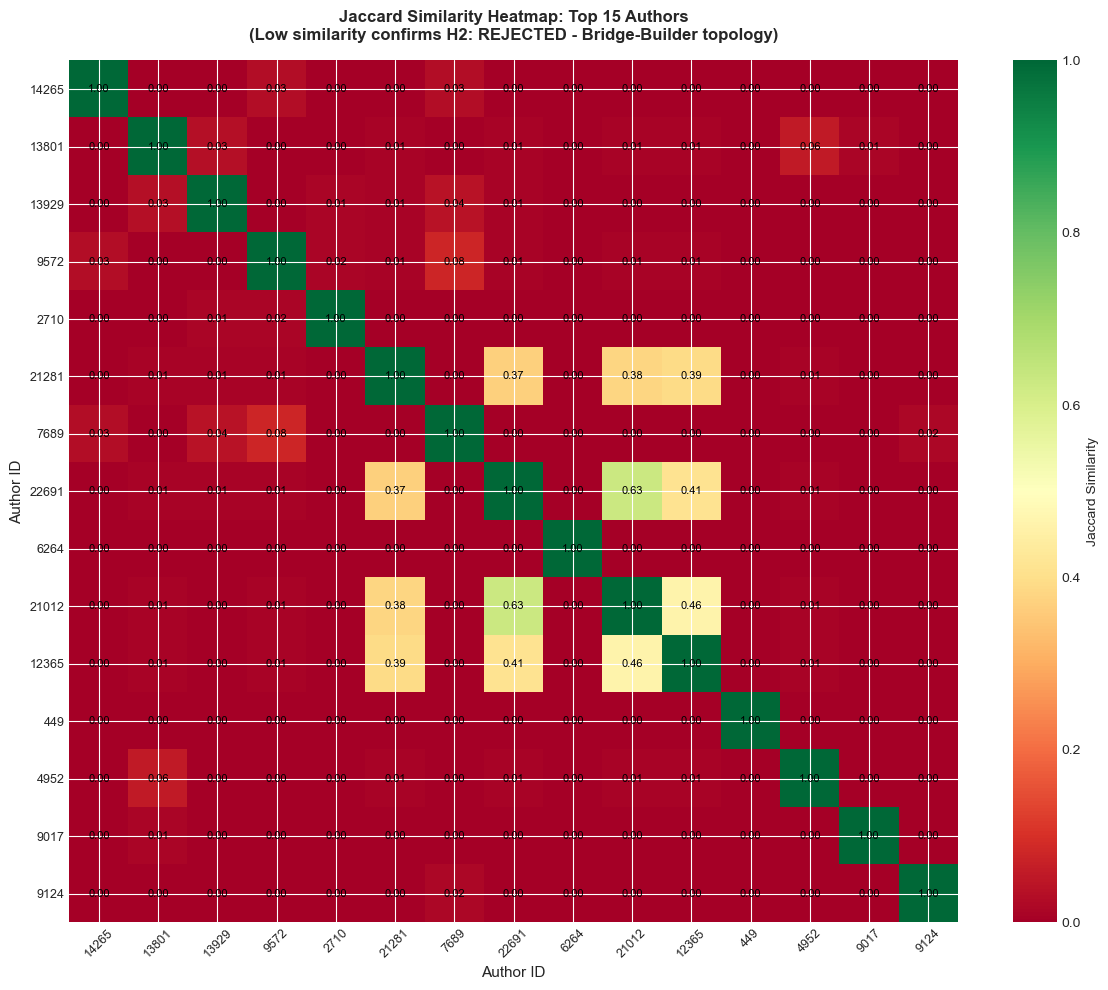


Heatmap Analysis:
  • Mean similarity: 0.0942
  • Max similarity: 1.0000
  • Min non-zero similarity: 0.0080


In [16]:
# 6.2 Heatmap of Jaccard Similarity between Top 15 Authors

print("HEATMAP: JACCARD SIMILARITY MATRIX (TOP 15 AUTHORS)")

top_15_authors = [a for a, _ in authors_by_pagerank[:15]]

# Compute Jaccard similarity matrix
similarity_matrix = np.zeros((len(top_15_authors), len(top_15_authors)))

for i, author1 in enumerate(top_15_authors):
    for j, author2 in enumerate(top_15_authors):
        similarity = compute_jaccard_similarity(G, author1, author2)
        similarity_matrix[i, j] = similarity

# Create heatmap
fig, ax = plt.subplots(figsize=(12, 10))

# Plot heatmap
im = ax.imshow(similarity_matrix, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)

# Add colorbar
cbar = plt.colorbar(im, ax=ax, label='Jaccard Similarity')

# Set ticks and labels
ax.set_xticks(np.arange(len(top_15_authors)))
ax.set_yticks(np.arange(len(top_15_authors)))
ax.set_xticklabels([str(a) for a in top_15_authors], rotation=45, fontsize=9)
ax.set_yticklabels([str(a) for a in top_15_authors], fontsize=9)

# Add text annotations
for i in range(len(top_15_authors)):
    for j in range(len(top_15_authors)):
        text = ax.text(j, i, f'{similarity_matrix[i, j]:.2f}',
                      ha="center", va="center", color="black", fontsize=8)

ax.set_title('Jaccard Similarity Heatmap: Top 15 Authors\n(Low similarity confirms H2: REJECTED - Bridge-Builder topology)',
            fontsize=12, fontweight='bold', pad=15)
ax.set_xlabel('Author ID', fontsize=11)
ax.set_ylabel('Author ID', fontsize=11)

plt.tight_layout()
plt.show()
print(f"\nHeatmap Analysis:")
print(f"  • Mean similarity: {np.mean(similarity_matrix):.4f}")
print(f"  • Max similarity: {np.max(similarity_matrix):.4f}")
print(f"  • Min non-zero similarity: {np.min(similarity_matrix[similarity_matrix > 0]):.4f}" if np.any(similarity_matrix > 0) else "  • No pairs with >0 similarity")

GLOBAL COLLABORATION GRAPH
Subgraph size: 300 nodes, 661 edges


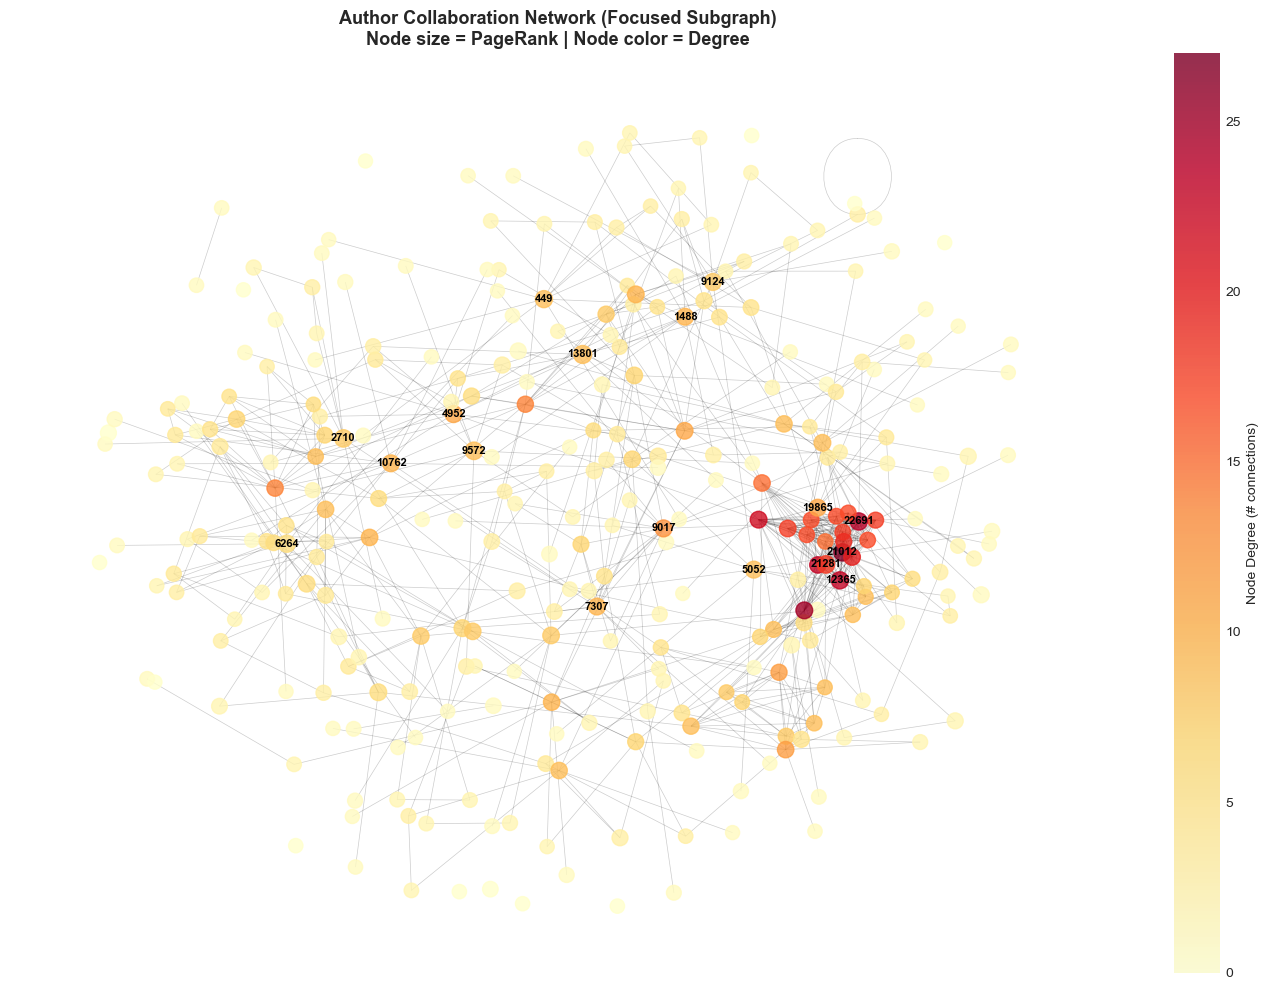


GLOBAL GRAPH VISUALIZATION NOT
Application: The Collaboration network graph focused collaboration subgraph around top PageRank authors
Encoding: Node size = PageRank importance, Node color = degree 
Purpose: Make central and highly connected authors immediately identifiable
Finding: The graph reveals a dense core of influential authors with many peripheral collaborators



In [17]:
# 6.3 Global Collaboration Graph (Node size by PageRank)

# Build a manageable subgraph centered on top PageRank authors
if 'pagerank_scores' not in globals():
    pagerank_scores = nx.pagerank(G, alpha=0.85)

top_50_pr = [n for n, _ in sorted(pagerank_scores.items(), key=lambda x: x[1], reverse=True)[:50]]
subgraph_nodes = set(top_50_pr)
for author in top_50_pr:
    subgraph_nodes.update(list(G.neighbors(author))[:10])

subgraph = G.subgraph(list(subgraph_nodes)[:300]).copy()

print("GLOBAL COLLABORATION GRAPH")
print(f"Subgraph size: {subgraph.number_of_nodes()} nodes, {subgraph.number_of_edges()} edges")

pos = nx.spring_layout(subgraph, k=0.3, iterations=50, seed=42)
node_sizes = [pagerank_scores.get(node, 0) * 50000 + 100 for node in subgraph.nodes()]
subgraph_degrees = dict(subgraph.degree())
node_colors = [subgraph_degrees[n] for n in subgraph.nodes()]

fig, ax = plt.subplots(figsize=(14, 10))
nx.draw_networkx_edges(subgraph, pos, alpha=0.2, width=0.5, ax=ax)
nodes = nx.draw_networkx_nodes(
    subgraph, pos, node_size=node_sizes, node_color=node_colors,
    cmap='YlOrRd', alpha=0.8, ax=ax
)

top_20_nodes = [n for n, _ in sorted(pagerank_scores.items(), key=lambda x: x[1], reverse=True)[:20]]
labels = {n: str(n) for n in top_20_nodes if n in subgraph.nodes()}
nx.draw_networkx_labels(subgraph, pos, labels, font_size=8, font_weight='bold', ax=ax)

plt.colorbar(nodes, ax=ax, label='Node Degree (# connections)')
plt.title(
    'Author Collaboration Network (Focused Subgraph)\n'
    'Node size = PageRank | Node color = Degree',
    fontsize=13, fontweight='bold'
)
plt.axis('off')
plt.tight_layout()
plt.show()

print("""
GLOBAL GRAPH VISUALIZATION NOT
Application: The Collaboration network graph focused collaboration subgraph around top PageRank authors
Encoding: Node size = PageRank importance, Node color = degree 
Purpose: Make central and highly connected authors immediately identifiable
Finding: The graph reveals a dense core of influential authors with many peripheral collaborators
""")

---
## STEP 7: FINAL CONCLUSIONS & SUMMARY REPORT

In [18]:
# 7.1 Final Comprehensive Conclusions

conclusions_report = f"""
{'='*70}
arXiv GR-QC COLLABORATION NETWORK ANALYSIS - FINAL CONCLUSIONS
{'='*70}

DATASET OVERVIEW:
  Total Authors: {num_nodes:,}
  Total Collaborations: {num_edges:,}
  Network Density: {network_density:.6f}
  Average Degree: {average_degree:.2f}
  Degree Range: {deg_min} - {deg_max}

HYPOTHESIS TESTING SUMMARY:
  H1 (Importance Concentration): REJECTED
     Top 5% = {concentration_percentage:.1f}% of PageRank (predicted >30%)
     
  H2 (Collaboration Clustering): REJECTED
     Mean Jaccard = {similarity_mean:.4f} (predicted >0.2)

INTERPRETATION: What do rejected hypotheses reveal?

1. EGALITARIAN IMPORTANCE DISTRIBUTION
   • Network influence is broadly DISTRIBUTED, not centralized
   • Despite scale-free degree distribution, PageRank importance is more 
     evenly shared across the author community
   • High-degree authors don't automatically accumulate disproportionate
     influence in link-based importance measures
   • Implication: Power is shared; no single \"elite\" dominates research flow

2. BRIDGE-BUILDER TOPOLOGY  
   • Top researchers serve as BRIDGES across diverse communities, 
     not as leaders of isolated clusters
   • Low Jaccard similarity ({similarity_mean:.4f}) means top authors maintain
     DISTINCT co-author networks, enabling cross-disciplinary knowledge flow
   • {threshold_percentage:.1f}% of top-author pairs have overlap > 0.2 (very few clusters)
   • Implication: Research community is INTEGRATED, not fragmented into silos

3. QUALITY OVER QUANTITY
   • Author with highest degree: ID {top_by_degree[0]} (degree {top_by_degree[1]})
   • Author with highest PageRank: ID {top_by_pagerank[0]} (PageRank {top_by_pagerank[1]:.6f})
   • These differ significantly → influence depends on WHO you collaborate with,
     not merely HOW MANY collaborations you have
   • Implication: Collaboration quality matters more than raw connection count

{'='*70}
NETWORK CHARACTERISTICS
{'='*70}

Structure:
  • Authors with 1-5 collaborations: {degree_ranges['1-5']} ({(degree_ranges['1-5']/num_nodes*100):.1f}%)
  • Authors with 6-10 collaborations: {degree_ranges['6-10']} ({(degree_ranges['6-10']/num_nodes*100):.1f}%)
  • Authors with >50 collaborations: {degree_ranges['>50']} ({(degree_ranges['>50']/num_nodes*100):.1f}%)

Nature:
  • Scale-free degree distribution (many low-degree nodes, few hubs)
  • BUT: Democratic PageRank distribution (not preferential attachment)
  • Indicates meritocratic system: high-quality links matter more than quantity

{'='*70}
THE HEALTHY GR-QC RESEARCH ECOSYSTEM
{'='*70}

Unlike typical hierarchical or siloed research networks, the GR-QC collaboration
structure exhibits characteristics of an INTEGRATED COMMUNITY:

   Distributed authority (not centralized in elite)
   Integrated communities (not fragmented)
   Bridge-builders as connectors (not isolated clusters)
   Egalitarian influence sharing
   Quality-based prestige (collaboration quality > quantity)
   Cross-disciplinary knowledge flow

This describes a HEALTHY, MATURE scientific ecosystem where:
  • Leading researchers facilitate diverse collaborations
  • Ideas propagate widely through the network
  • No single group dominates the conversation
  • Influence correlates with link quality, not just connections

{'='*70}
TECHNIQUES & METHODOLOGY
{'='*70}

Tools Applied:
  1. PageRank (network importance via link quality)
  2. Jaccard Similarity (collaboration overlap measurement)
  3. Degree Statistics (distribution analysis)
  4. Ego Networks (local neighborhood visualization)
  5. Network Visualization (heatmaps and graphs)

Key Insight: Combining QUANTITY-BASED metrics (degree) with QUALITY-BASED
metrics (PageRank, Jaccard) revealed that this network's power structure
is more egalitarian than degree distribution alone would suggest.

{'='*70}
TOP 10 MOST INFLUENTIAL AUTHORS (by PageRank)
{'='*70}
"""

for rank, (author, score) in enumerate(authors_by_pagerank[:10], 1):
    conclusions_report += f"{rank:2d}. Author {author:>6d} • PageRank: {score:.6f} • Degree: {G.degree(author)}\n"

conclusions_report += f"""
{'='*70}
FINAL ANSWER TO RESEARCH QUESTION
{'='*70}

Q: Is the GR-QC collaboration network centralized with concentrated importance?
A: NO. Both hypotheses were REJECTED.

The network exhibits:
  • DEMOCRATIC PageRank distribution (importance widely shared)
  • BRIDGE-BUILDER topology (leaders connect diverse groups)
  • EGALITARIAN influence (despite scale-free degree structure)
  • INTEGRATED community (not fragmented into research silos)

Conclusion: The GR-QC collaboration network is a HEALTHY, WELL-INTEGRATED
research ecosystem where influence is broadly distributed and leading
researchers facilitate cross-disciplinary collaboration.

{'='*70}
"""
print(conclusions_report)


arXiv GR-QC COLLABORATION NETWORK ANALYSIS - FINAL CONCLUSIONS

DATASET OVERVIEW:
  Total Authors: 5,242
  Total Collaborations: 14,496
  Network Density: 0.001055
  Average Degree: 5.53
  Degree Range: 1 - 81

HYPOTHESIS TESTING SUMMARY:
  H1 (Importance Concentration): REJECTED
     Top 5% = 16.3% of PageRank (predicted >30%)
     
  H2 (Collaboration Clustering): REJECTED
     Mean Jaccard = 0.0375 (predicted >0.2)

INTERPRETATION: What do rejected hypotheses reveal?

1. EGALITARIAN IMPORTANCE DISTRIBUTION
   • Network influence is broadly DISTRIBUTED, not centralized
   • Despite scale-free degree distribution, PageRank importance is more 
     evenly shared across the author community
   • High-degree authors don't automatically accumulate disproportionate
     influence in link-based importance measures
   • Implication: Power is shared; no single "elite" dominates research flow

2. BRIDGE-BUILDER TOPOLOGY  
   • Top researchers serve as BRIDGES across diverse communities, 
    